In [ ]:
#P1
#TASK 1: DATASET PREPARATION (COMPREHENSIVE IIT JODHPUR CORPUS)       ║


!pip install gensim nltk beautifulsoup4 requests matplotlib scikit-learn wordcloud pandas tabulate numpy lxml -q

import os, re, time, pickle, string
from collections import Counter
from urllib.parse import urljoin, urlparse

import requests
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import pandas as pd

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

for d in ['data', 'models', 'outputs']:
    os.makedirs(d, exist_ok=True)

print('=' * 70)
print('TASK 1: DATASET PREPARATION (COMPREHENSIVE CORPUS)')
print('=' * 70)

documents = []

# ================= SOURCE 1 =================
file_path = 'campus_data.txt'

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
        file_docs = [doc.strip() for doc in content.split('\n\n') if doc.strip()]
        documents.extend(file_docs)
        print(f'\n  [SOURCE 1] Loaded {len(file_docs)} documents from {file_path}')
except FileNotFoundError:
    print(f'\n  [ERROR] File {file_path} not found.')

# ================= SOURCE 2 =================
SEED_URLS = [
    'https://iitj.ac.in/PageImages/Gallery/07-2025/CSE-Courses-Details.pdf',
    'https://iitj.ac.in/PageImages/Gallery/03-2025/1_Academic_Regulations_Final_03_09_2019.pdf',
    'https://iitj.ac.in/PageImages/Gallery/03-2025/4_Regulation_PG_2022-onwards_20022023.pdf',
    'https://www.iitj.ac.in/computer-science-engineering/',
    'https://www.iitj.ac.in/main/en/news',
    'https://www.iitj.ac.in/main/en/all-announcement',  # ✅ FIXED comma

    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=cse',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=ee',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=me',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=ma',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=ph',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=ch',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=civil',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=bs',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=hss',
    'https://iitj.ac.in/department/index.php?id=dept_page&&dept=mt',
    'https://iitj.ac.in/academics/index.php?id=curr_btech',
    'https://iitj.ac.in/academics/index.php?id=curr_mtech',
    'https://iitj.ac.in/academics/index.php?id=curr_msc',
    'https://iitj.ac.in/academics/index.php?id=curr_phd',
    'https://iitj.ac.in/academics/index.php?id=programmes',
    'https://iitj.ac.in/academics/index.php?id=admissions',
    'https://iitj.ac.in/research/index.php',
    'https://iitj.ac.in/research/index.php?id=sponsored_research',
    'https://iitj.ac.in/research/index.php?id=research_centers',
    'https://iitj.ac.in/academics/index.php?id=ordinances_and_regulations',
    'https://iitj.ac.in/department/index.php?id=faculty&&dept=cse',
    'https://iitj.ac.in/department/index.php?id=faculty&&dept=ee',
    'https://iitj.ac.in/department/index.php?id=faculty&&dept=me',
    'https://iitj.ac.in/about/index.php',
    'https://iitj.ac.in/about/index.php?id=vision_mission',
    'https://iitj.ac.in/about/index.php?id=director_message',
    'https://iitj.ac.in/placement/index.php',
    'https://iitj.ac.in/student-life/index.php',
    'https://iitj.ac.in/default.php',
    'https://www.iitj.ac.in/computer-science-engineering/en/projects/',
    'https://www.iitj.ac.in/computer-science-engineering/en/',
]

MAX_CRAWL_PAGES = 120
CRAWL_DELAY = 0.8
REQUEST_TIMEOUT = 15
ALLOWED_DOMAIN = 'iitj.ac.in'
MIN_TOKEN_LEN = 2
MIN_DOC_TOKENS = 5

def fetch_page(url, session):
    try:
        resp = session.get(url, timeout=REQUEST_TIMEOUT)
        resp.raise_for_status()
        if 'text/html' not in resp.headers.get('Content-Type', ''):
            return None
        return resp.text
    except Exception:
        return None

def extract_text(html):
    soup = BeautifulSoup(html, 'lxml')
    for tag in soup(['script','style','nav','footer','header','noscript','meta','link','iframe','svg']):
        tag.decompose()
    return soup.get_text(separator=' ', strip=True)

def extract_links(html, base_url):
    soup = BeautifulSoup(html, 'lxml')
    links = set()
    for a in soup.find_all('a', href=True):
        full = urljoin(base_url, a['href'])
        parsed = urlparse(full)
        if ALLOWED_DOMAIN in parsed.netloc:
            links.add(parsed.geturl())
    return links

print(f'\n  [SOURCE 2] Scraping IIT Jodhpur website ...')

session = requests.Session()
visited = set()
to_visit = list(SEED_URLS)
scraped_count = 0

while to_visit and len(visited) < MAX_CRAWL_PAGES:
    url = to_visit.pop(0)
    if url in visited:
        continue
    visited.add(url)

    html = fetch_page(url, session)
    if html is None:
        continue

    text = extract_text(html)
    if len(text.split()) > 15:
        documents.append(text)
        scraped_count += 1

    for link in extract_links(html, url):
        if link not in visited:
            to_visit.append(link)

    time.sleep(CRAWL_DELAY)

print(f'\n  Pages scraped: {scraped_count}')
print(f'  Total documents: {len(documents)}')

# ================= ✅ RAW CORPUS SAVE =================
raw_path = 'data/raw_corpus.txt'
with open(raw_path, 'w', encoding='utf-8') as f:
    for doc in documents:
        f.write(doc + '\n===DOC_SEPARATOR===\n')
print(f'✅ Raw corpus saved at: {raw_path}')

# ================= PREPROCESSING =================
stop_words = set(stopwords.words('english'))

tokenized_docs = []

for doc in documents:
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', doc.lower())
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) >= 2]
    if len(tokens) >= 5:
        tokenized_docs.append(tokens)

# ================= ✅ CLEAN CORPUS SAVE =================
clean_path = 'data/clean_corpus.txt'
with open(clean_path, 'w', encoding='utf-8') as f:
    for tokens in tokenized_docs:
        f.write(' '.join(tokens) + '\n')
print(f'✅ Clean corpus saved at: {clean_path}')

with open('data/tokenized_corpus.pkl', 'wb') as f:
    pickle.dump(tokenized_docs, f)

print('\nTASK COMPLETE ✓')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 33.9 MB/s eta 0:00:00
TASK 1: DATASET PREPARATION (COMPREHENSIVE CORPUS)

  [ERROR] File campus_data.txt not found.

  [SOURCE 2] Scraping IIT Jodhpur website ...


KeyboardInterrupt: 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



DATASET STATISTICS (FROM CLEAN CORPUS FILE)
Total Documents   : 82
Total Tokens      : 37026
Vocabulary Size   : 5349
Avg Tokens/Doc    : 451.54

Top 20 Frequent Words:
 1. department      -> 1266
 2. jodhpur         -> 576
 3. engineering     -> 446
 4. iit             -> 355
 5. technology      -> 303
 6. science         -> 293
 7. institute       -> 292
 8. iitj            -> 292
 9. office          -> 270
10. research        -> 239
11. computer        -> 228
12. information     -> 215
13. tech            -> 206
14. contact         -> 206
15. web             -> 190
16. digital         -> 181
17. links           -> 177
18. infrastructure  -> 175
19. portal          -> 173
20. school          -> 173

✅ Stats saved to TXT: outputs/dataset_statistics.txt
✅ Stats saved to CSV: outputs/top_words.csv

Generating Word Cloud...


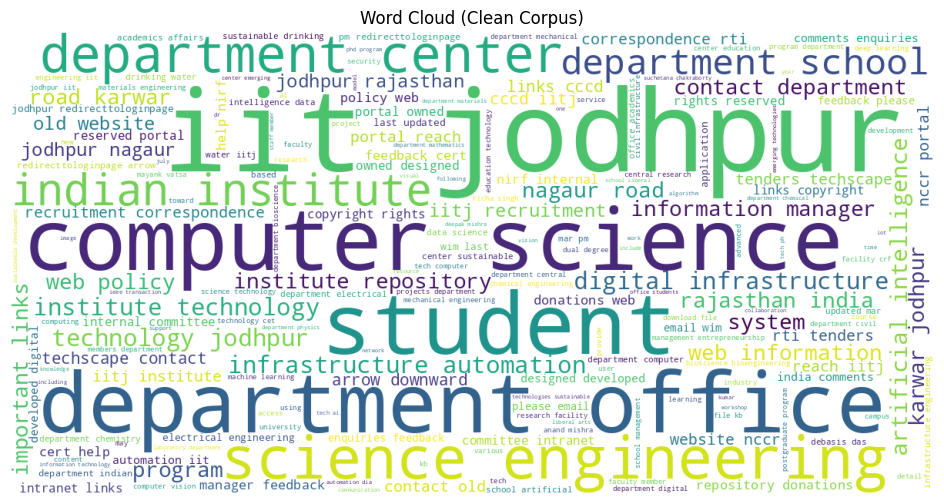


Generating Frequency Chart...


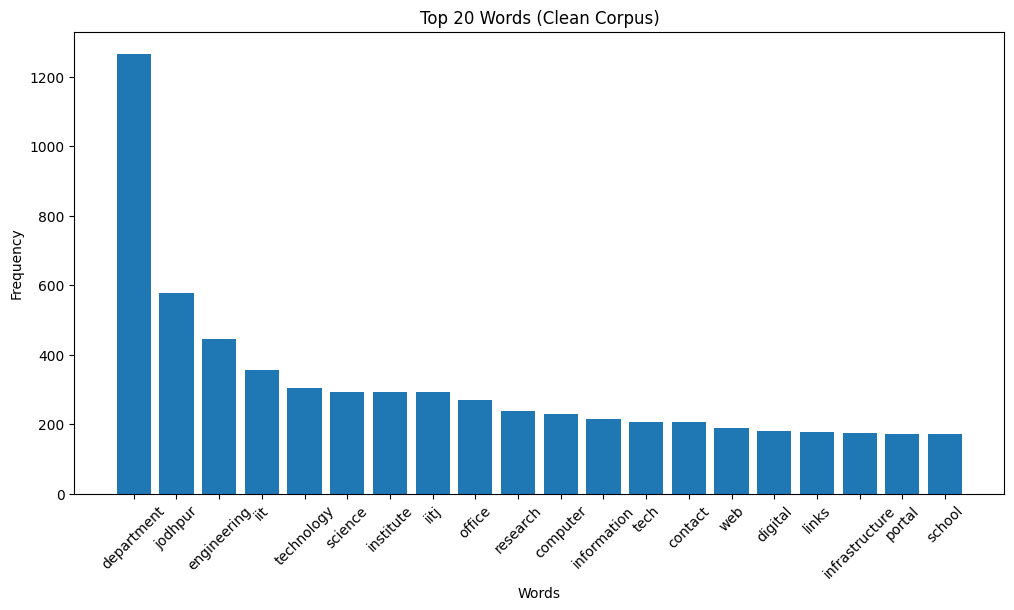

In [ ]:
# ════════════════════════════════════════════════════════════════════════════════
#DATASET STATISTICS CREATED FROM CLEAN CORPUS FILE
# ════════════════════════════════════════════════════════════════════════════════

print('\n' + '='*60)
print('DATASET STATISTICS (FROM CLEAN CORPUS FILE)')
print('='*60)

clean_path = '/content/drive/MyDrive/CORPUS NLU A2/clean_corpus.txt'

# Read clean corpus
with open(clean_path, 'r', encoding='utf-8') as f:
    lines = [line.strip() for line in f.readlines() if line.strip()]

# Convert into tokens
docs = [line.split() for line in lines]

# Flatten tokens
all_tokens = [token for doc in docs for token in doc]

# Stats
total_docs = len(docs)
total_tokens = len(all_tokens)
vocab = set(all_tokens)
vocab_size = len(vocab)

print(f'Total Documents   : {total_docs}')
print(f'Total Tokens      : {total_tokens}')
print(f'Vocabulary Size   : {vocab_size}')
print(f'Avg Tokens/Doc    : {total_tokens / max(total_docs,1):.2f}')

# Frequency
from collections import Counter
freq = Counter(all_tokens)
top_words = freq.most_common(20)

print('\nTop 20 Frequent Words:')
for i, (word, count) in enumerate(top_words, 1):
    print(f'{i:2d}. {word:15s} -> {count}')


# ════════════════════════════════════════════════════════════════════════════════
# ✅ SAVE STATS TO TXT
# ════════════════════════════════════════════════════════════════════════════════

stats_txt_path = 'outputs/dataset_statistics.txt'

with open(stats_txt_path, 'w', encoding='utf-8') as f:
    f.write('DATASET STATISTICS\n')
    f.write('='*40 + '\n\n')
    f.write(f'Total Documents : {total_docs}\n')
    f.write(f'Total Tokens    : {total_tokens}\n')
    f.write(f'Vocabulary Size : {vocab_size}\n')
    f.write(f'Avg Tokens/Doc  : {total_tokens / max(total_docs,1):.2f}\n\n')

    f.write('Top 20 Frequent Words:\n')
    for i, (word, count) in enumerate(top_words, 1):
        f.write(f'{i:2d}. {word:15s} -> {count}\n')

print(f'\n✅ Stats saved to TXT: {stats_txt_path}')


# ════════════════════════════════════════════════════════════════════════════════
# ✅ SAVE STATS TO CSV
# ════════════════════════════════════════════════════════════════════════════════

import pandas as pd

stats_csv_path = 'outputs/top_words.csv'

df = pd.DataFrame(top_words, columns=['Word', 'Frequency'])
df.to_csv(stats_csv_path, index=False)

print(f'✅ Stats saved to CSV: {stats_csv_path}')


# ════════════════════════════════════════════════════════════════════════════════
# ✅ WORD CLOUD (FROM CLEAN CORPUS)
# ════════════════════════════════════════════════════════════════════════════════

from wordcloud import WordCloud
import matplotlib.pyplot as plt

print('\nGenerating Word Cloud...')

text_for_wc = ' '.join(all_tokens)

wc = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(text_for_wc)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis('off')
plt.title('Word Cloud (Clean Corpus)')
plt.show()


# ════════════════════════════════════════════════════════════════════════════════
# ✅ FREQUENCY BAR CHART
# ════════════════════════════════════════════════════════════════════════════════

print('\nGenerating Frequency Chart...')

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title('Top 20 Words (Clean Corpus)')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

In [3]:
!pip install numpy pandas matplotlib

   TASK-2: WORD2VEC FROM SCRATCH (Vectorised NumPy)

Vocab=2975  |  Tokens=34652
After subsampling: 26258 tokens

════════════════════════════════════════════════════════════
  MODEL : CBOW
════════════════════════════════════════════════════════════

  dim=100 | win=2 | neg=5
  ──────────────────────────────────────
    Epoch 1/5  |  loss=4.1563  |  time=0.6s
    Epoch 2/5  |  loss=4.1267  |  time=0.9s
    Epoch 3/5  |  loss=3.9242  |  time=1.1s
    Epoch 4/5  |  loss=3.5156  |  time=1.1s
    Epoch 5/5  |  loss=3.1264  |  time=1.1s

  dim=100 | win=2 | neg=10
  ──────────────────────────────────────
    Epoch 1/5  |  loss=7.5616  |  time=1.9s
    Epoch 2/5  |  loss=6.0823  |  time=1.3s
    Epoch 3/5  |  loss=4.3933  |  time=1.1s
    Epoch 4/5  |  loss=3.6908  |  time=1.2s
    Epoch 5/5  |  loss=3.3128  |  time=1.2s

  dim=100 | win=2 | neg=15
  ──────────────────────────────────────
    Epoch 1/5  |  loss=10.4307  |  time=1.5s
    Epoch 2/5  |  loss=6.0673  |  time=1.5s
    Epoch 3/5 

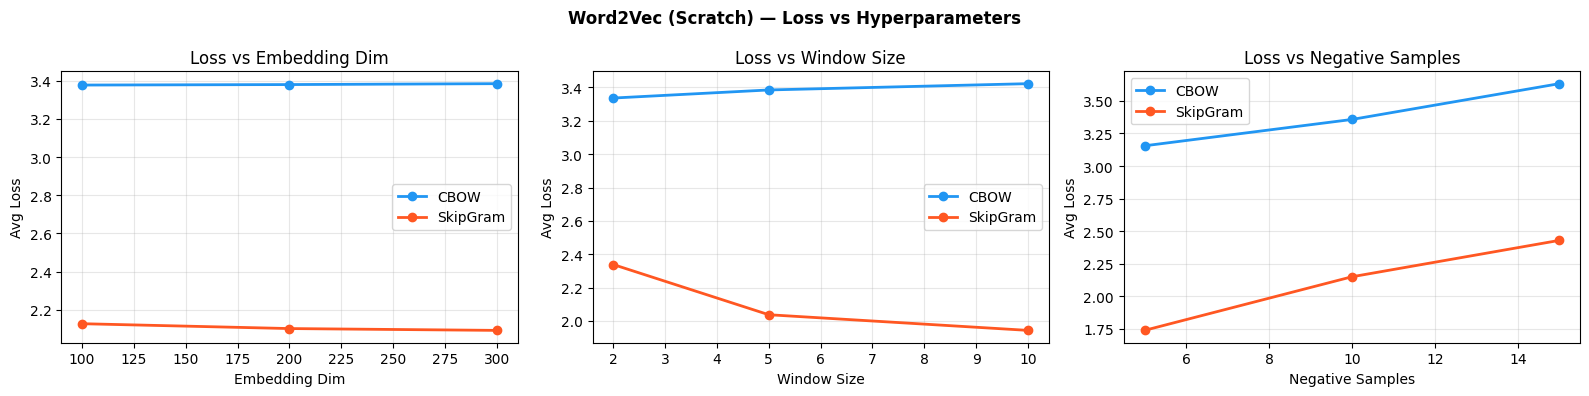


[✓] Plot saved. Done!


In [4]:
"""
Task-2: Word2Vec FROM SCRATCH — Optimised (Pure NumPy)
=======================================================
Logic is 100% manual (no Gensim/PyTorch autograd).
Speed gains over the naive version:
  ✦ Mini-batch vectorised forward + backward (no per-pair Python loop)
  ✦ Frequent-word subsampling (skip boring words like "the", "of")
  ✦ Pre-built negative sample batches (one numpy call, not a while-loop)
  ✦ NumPy advanced indexing for weight updates (np.add.at)
"""

import numpy as np
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random

CORPUS_PATH = "/content/drive/MyDrive/CORPUS NLU A2/clean_corpus.txt"

# ══════════════════════════════════════════════════════════
# 1. CORPUS & VOCABULARY
# ══════════════════════════════════════════════════════════

def load_and_tokenize(path, min_count=2):
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read().lower().split()

    freq     = Counter(raw)
    word2idx = {w: i for i, (w, c) in
                enumerate((w, c) for w, c in freq.items() if c >= min_count)}
    idx2word = {i: w for w, i in word2idx.items()}
    # convert corpus to integer ids (drop OOV)
    corpus   = [word2idx[w] for w in raw if w in word2idx]
    return corpus, word2idx, idx2word, freq

def subsample(corpus, word2idx, freq, threshold=1e-3):
    """
    Mikolov's subsampling: skip frequent words with probability
        P(w) = 1 - sqrt(t / f(w))
    This removes 'the', 'of', etc. and speeds up training ~2x.
    """
    total   = len(corpus)
    keep_p  = {}
    for w, idx in word2idx.items():
        f = freq[w] / total
        keep_p[idx] = max(0.0, 1.0 - math.sqrt(threshold / f))

    return [idx for idx in corpus
            if random.random() > keep_p.get(idx, 0.0)]

# ══════════════════════════════════════════════════════════
# 2. NEGATIVE SAMPLING TABLE  (freq^0.75 noise distribution)
# ══════════════════════════════════════════════════════════

def build_neg_table(word2idx, freq, size=500_000):
    vocab    = list(word2idx.keys())
    counts   = np.array([freq[w] ** 0.75 for w in vocab], dtype=np.float32)
    probs    = counts / counts.sum()
    ids      = np.array([word2idx[w] for w in vocab], dtype=np.int32)
    table    = np.random.choice(ids, size=size, p=probs)
    return table

def sample_negatives_batch(neg_table, positive_ids, k, vocab_size):
    """
    Draw k negatives for every row in positive_ids at once.
    Returns shape (N, k).
    vocab_size is used for replacement modulo so indices stay in [0, V).
    """
    N    = len(positive_ids)
    idxs = np.random.randint(0, len(neg_table), size=(N, k))
    negs = neg_table[idxs]                              # (N, k)
    # replace any accidental positives
    mask          = (negs == positive_ids[:, None])     # (N, k) bool
    pos_broadcast = np.tile(positive_ids[:, None], (1, k))  # (N, k)
    # ✅ mod by vocab_size (NOT neg_table length) — keeps indices in [0, V)
    negs[mask]    = (pos_broadcast[mask] + 1) % vocab_size
    return negs                                         # (N, k)

# ══════════════════════════════════════════════════════════
# 3. PAIR GENERATION
# ══════════════════════════════════════════════════════════

def build_cbow_pairs(corpus, window):
    """Returns arrays: context_ids (N,2w), center_ids (N,)"""
    contexts, centers = [], []
    n = len(corpus)
    for i in range(window, n - window):
        ctx = list(corpus[i - window: i]) + list(corpus[i + 1: i + window + 1])
        contexts.append(ctx)
        centers.append(corpus[i])
    return np.array(contexts, dtype=np.int32), np.array(centers, dtype=np.int32)

def build_skipgram_pairs(corpus, window):
    """Returns arrays: center_ids (N,), context_ids (N,)"""
    centers, contexts = [], []
    n = len(corpus)
    for i in range(window, n - window):
        for j in range(i - window, i + window + 1):
            if j != i:
                centers.append(corpus[i])
                contexts.append(corpus[j])
    return np.array(centers, dtype=np.int32), np.array(contexts, dtype=np.int32)

# ══════════════════════════════════════════════════════════
# 4. MATH
# ══════════════════════════════════════════════════════════

def sigmoid(x):
    """Vectorised numerically-stable sigmoid."""
    out = np.empty_like(x, dtype=np.float32)
    pos = x >= 0
    out[ pos] = 1.0 / (1.0 + np.exp(-x[ pos]))
    exp_neg   = np.exp(x[~pos])
    out[~pos] = exp_neg / (1.0 + exp_neg)
    return out

# ══════════════════════════════════════════════════════════
# 5. CBOW — MINI-BATCH VECTORISED TRAINING
# ══════════════════════════════════════════════════════════
#
#  Forward (batch of B samples):
#   ctx_vecs  = W_in[context_ids]           (B, C, D)
#   h         = ctx_vecs.mean(axis=1)       (B, D)   ← hidden layer
#   score_pos = (h * W_out[center]).sum(-1) (B,)
#   score_neg = h @ W_out[neg_ids].T        → (B, K) via einsum
#
#  Backward:
#   grad_W_out(pos)  = (σ(score_pos)-1)[:,None] * h         (B, D)
#   grad_W_out(neg)  = σ(score_neg)[:,:,None]   * h[:,None] (B, K, D)
#   grad_h           = (σ-1)·v_pos + Σ_k σ·v_neg            (B, D)
#   grad_W_in(ctx)   = grad_h / C   broadcast to (B, C, D)
#
#  Weight update uses np.add.at for correct repeated-index accumulation.

def train_cbow_batch(W_in, W_out, context_ids, center_ids, neg_ids, lr):
    """
    context_ids : (B, C)
    center_ids  : (B,)
    neg_ids     : (B, K)
    """
    B, C = context_ids.shape
    K    = neg_ids.shape[1]

    # ── Forward ──────────────────────────────────────────
    ctx_vecs  = W_in[context_ids]                    # (B, C, D)
    h         = ctx_vecs.mean(axis=1)                # (B, D)

    v_pos     = W_out[center_ids]                    # (B, D)
    v_negs    = W_out[neg_ids]                       # (B, K, D)

    score_pos  = (h * v_pos).sum(axis=-1)            # (B,)
    score_neg  = np.einsum('bd,bkd->bk', h, v_negs) # (B, K)

    p_pos  = sigmoid(score_pos)                      # (B,)
    p_negs = sigmoid(score_neg)                      # (B, K)

    # ── Loss (mean over batch) ────────────────────────────
    loss = (-np.log(p_pos + 1e-7)
            - np.log(1 - p_negs + 1e-7).sum(axis=1)).mean()

    # ── Backward ─────────────────────────────────────────
    # gradient on output embeddings
    err_pos  = (p_pos - 1.0)[:, None]               # (B, 1)
    err_negs = p_negs[:, :, None]                    # (B, K, 1)

    dW_out_pos = err_pos  * h                        # (B, D)
    dW_out_neg = err_negs * h[:, None, :]            # (B, K, D)

    # gradient flowing back to h
    grad_h = (err_pos * v_pos
              + (err_negs * v_negs).sum(axis=1))     # (B, D)

    # gradient to each context word embedding
    grad_ctx = (grad_h / C)[:, None, :]              # (B, 1, D)
    grad_ctx = np.broadcast_to(grad_ctx,
                    ctx_vecs.shape).copy()            # (B, C, D)

    # ── Weight update ─────────────────────────────────────
    # np.add.at handles repeated indices correctly
    np.add.at(W_out, center_ids,  -lr * dW_out_pos)
    np.add.at(W_out, neg_ids,     -lr * dW_out_neg)
    np.add.at(W_in,  context_ids, -lr * grad_ctx)

    return loss



def train_skipgram_batch(W_in, W_out, center_ids, context_ids, neg_ids, lr):
    """
    center_ids  : (B,)
    context_ids : (B,)
    neg_ids     : (B, K)
    """
    K = neg_ids.shape[1]

    # ── Forward ──────────────────────────────────────────
    h      = W_in[center_ids]                        # (B, D)
    v_pos  = W_out[context_ids]                      # (B, D)
    v_negs = W_out[neg_ids]                          # (B, K, D)

    score_pos  = (h * v_pos).sum(axis=-1)            # (B,)
    score_neg  = np.einsum('bd,bkd->bk', h, v_negs) # (B, K)

    p_pos  = sigmoid(score_pos)                      # (B,)
    p_negs = sigmoid(score_neg)                      # (B, K)

    # ── Loss ─────────────────────────────────────────────
    loss = (-np.log(p_pos + 1e-7)
            - np.log(1 - p_negs + 1e-7).sum(axis=1)).mean()

    # ── Backward ─────────────────────────────────────────
    err_pos  = (p_pos - 1.0)[:, None]               # (B, 1)
    err_negs = p_negs[:, :, None]                    # (B, K, 1)

    dW_out_pos = err_pos  * h                        # (B, D)
    dW_out_neg = err_negs * h[:, None, :]            # (B, K, D)

    grad_h = (err_pos * v_pos
              + (err_negs * v_negs).sum(axis=1))     # (B, D)

    # ── Weight update ─────────────────────────────────────
    np.add.at(W_out, context_ids, -lr * dW_out_pos)
    np.add.at(W_out, neg_ids,     -lr * dW_out_neg)
    np.add.at(W_in,  center_ids,  -lr * grad_h)

    return loss

# ══════════════════════════════════════════════════════════
# 7. FULL TRAINING RUNNER
# ══════════════════════════════════════════════════════════

def train(model_type, corpus, word2idx, freq,
          emb_dim, window, neg_k,
          epochs=5, lr=0.025, batch_size=512, seed=42):

    np.random.seed(seed); random.seed(seed)
    V         = len(word2idx)
    neg_table = build_neg_table(word2idx, freq)

    # ── Weight initialisation ──
    scale = np.sqrt(1.0 / emb_dim)
    W_in  = np.random.uniform(-scale, scale, (V, emb_dim)).astype(np.float32)
    W_out = np.zeros((V, emb_dim), dtype=np.float32)

    # ── Build all training pairs once ──
    if model_type == "CBOW":
        ctx_arr, ctr_arr = build_cbow_pairs(corpus, window)
        N = len(ctr_arr)
    else:
        ctr_arr, ctx_arr = build_skipgram_pairs(corpus, window)
        N = len(ctr_arr)

    epoch_losses = []

    for epoch in range(1, epochs + 1):
        # shuffle pair indices
        perm     = np.random.permutation(N)
        ctx_arr  = ctx_arr[perm]
        ctr_arr  = ctr_arr[perm]

        total_loss, n_batches = 0.0, 0
        t0 = time.time()

        for start in range(0, N, batch_size):
            end      = min(start + batch_size, N)
            b_ctx    = ctx_arr[start:end]            # (B, C) or (B,)
            b_ctr    = ctr_arr[start:end]            # (B,)

            if model_type == "CBOW":
                # b_ctx: (B, C),  b_ctr: positive (center)
                neg_ids = sample_negatives_batch(neg_table, b_ctr, neg_k, V)
                loss    = train_cbow_batch(
                    W_in, W_out, b_ctx, b_ctr, neg_ids, lr)
            else:
                # b_ctr: center,  b_ctx: positive (context)
                neg_ids = sample_negatives_batch(neg_table, b_ctx, neg_k, V)
                loss    = train_skipgram_batch(
                    W_in, W_out, b_ctr, b_ctx, neg_ids, lr)

            total_loss += loss
            n_batches  += 1

        avg_loss = total_loss / n_batches
        epoch_losses.append(avg_loss)
        elapsed = time.time() - t0
        print(f"    Epoch {epoch}/{epochs}  |  loss={avg_loss:.4f}"
              f"  |  time={elapsed:.1f}s")

    return W_in, W_out, epoch_losses

# ══════════════════════════════════════════════════════════
# 8. COSINE SIMILARITY HELPER
# ══════════════════════════════════════════════════════════

def most_similar(W_in, word2idx, idx2word, query, topn=5):
    if query not in word2idx:
        print(f"  '{query}' not in vocab"); return
    qvec  = W_in[word2idx[query]]
    norms = np.linalg.norm(W_in, axis=1, keepdims=True) + 1e-10
    sims  = (W_in @ qvec) / (norms.squeeze() * np.linalg.norm(qvec) + 1e-10)
    sims[word2idx[query]] = -1               # exclude self
    top   = np.argsort(sims)[::-1][:topn]
    print(f"\n  Top-{topn} similar to '{query}':")
    for i in top:
        print(f"    {idx2word[i]:<25} cosine={sims[i]:.4f}")

# ══════════════════════════════════════════════════════════
# 9. EXPERIMENT GRID + REPORTING
# ══════════════════════════════════════════════════════════

if __name__ == "__main__":

    print("=" * 60)
    print("   TASK-2: WORD2VEC FROM SCRATCH (Vectorised NumPy)")
    print("=" * 60)

    # ── Load ──
    corpus, word2idx, idx2word, freq = load_and_tokenize(CORPUS_PATH, min_count=2)
    print(f"\nVocab={len(word2idx)}  |  Tokens={len(corpus)}")

    # ── Subsample frequent words ──
    corpus = subsample(corpus, word2idx, freq)
    print(f"After subsampling: {len(corpus)} tokens")

    # ── Hyperparameter grid ──
    EMB_DIMS = [100, 200, 300]
    WINDOWS  = [2, 5, 10]
    NEG_KS   = [5, 10, 15]
    EPOCHS   = 5
    LR       = 0.025
    BATCH    = 512

    results     = []
    best_W      = {}      # store best W_in per model type

    for model_type in ["CBOW", "SkipGram"]:
        print(f"\n{'═'*60}")
        print(f"  MODEL : {model_type}")
        print(f"{'═'*60}")
        best_loss = math.inf
        best_Win  = None

        for emb_dim in EMB_DIMS:
            for window in WINDOWS:
                for neg_k in NEG_KS:
                    print(f"\n  dim={emb_dim} | win={window} | neg={neg_k}")
                    print(f"  {'─'*38}")

                    W_in, W_out, losses = train(
                        model_type = model_type,
                        corpus     = corpus,
                        word2idx   = word2idx,
                        freq       = freq,
                        emb_dim    = emb_dim,
                        window     = window,
                        neg_k      = neg_k,
                        epochs     = EPOCHS,
                        lr         = LR,
                        batch_size = BATCH,
                    )
                    final = losses[-1]
                    results.append({
                        "Model"           : model_type,
                        "Embedding_Dim"   : emb_dim,
                        "Window_Size"     : window,
                        "Negative_Samples": neg_k,
                        "Final_Loss"      : round(final, 4),
                    })
                    if final < best_loss:
                        best_loss = final
                        best_Win  = (W_in, emb_dim, window, neg_k)

        best_W[model_type] = best_Win

        print(f"\n  ✓ Best {model_type} loss: {best_loss:.4f}")

    #------------------------------------------
    ######SAVE BEST MODELS FOR TASK-3
    # ============================================
    BEST_MODEL = {
        "CBOW": best_W["CBOW"][0],
        "SkipGram": best_W["SkipGram"][0]
    }
    print("\n[✓] Best models stored in BEST_MODEL")

    np.save("best_cbow.npy", BEST_MODEL["CBOW"])
    np.save("best_skipgram.npy", BEST_MODEL["SkipGram"])
    print("[✓] Models saved to disk")

    #---------------------------------------

    # ── Table ──
    df = pd.DataFrame(results)
    print("\n\n" + "=" * 60)
    print("  RESULTS TABLE")
    print("=" * 60)
    print(df.to_string(index=False))
    df.to_csv("task2_results.csv", index=False)
    print("\n[✓] Saved task2_results.csv")

    # ── Best configs ──
    print("\n" + "=" * 60)
    print("  BEST CONFIGURATIONS")
    print("=" * 60)
    for mtype in ["CBOW", "SkipGram"]:
        row = df[df["Model"] == mtype].sort_values("Final_Loss").iloc[0]
        print(f"\n  {mtype}:")
        print(f"    Embedding Dim    : {int(row.Embedding_Dim)}")
        print(f"    Window Size      : {int(row.Window_Size)}")
        print(f"    Negative Samples : {int(row.Negative_Samples)}")
        print(f"    Final Loss       : {row.Final_Loss}")

    # ── Similarity test ──
    print("\n" + "=" * 60)
    print("  SIMILARITY TEST (Best Models)")
    print("=" * 60)
    test_words = ["computer", "learning", "engineering", "research", "data"]
    for mtype, (W_in, ed, ws, nk) in best_W.items():
        print(f"\n  [{mtype}] (dim={ed}, win={ws}, neg={nk})")
        tw = next((w for w in test_words if w in word2idx), list(word2idx)[0])
        most_similar(W_in, word2idx, idx2word, tw)

    # ── Plot ──
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("Word2Vec (Scratch) — Loss vs Hyperparameters", fontweight="bold")
    params  = ["Embedding_Dim", "Window_Size", "Negative_Samples"]
    xlabels = ["Embedding Dim",  "Window Size", "Negative Samples"]
    colors  = {"CBOW": "#2196F3", "SkipGram": "#FF5722"}
    for ax, p, xl in zip(axes, params, xlabels):
        for mt in ["CBOW", "SkipGram"]:
            sub = (df[df["Model"]==mt].groupby(p)["Final_Loss"]
                   .mean().reset_index())
            ax.plot(sub[p], sub["Final_Loss"], marker="o",
                    label=mt, color=colors[mt], lw=2)
        ax.set_xlabel(xl); ax.set_ylabel("Avg Loss")
        ax.set_title(f"Loss vs {xl}"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("task2_plots.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n[✓] Plot saved. Done!")

In [5]:
# ============================================
# TASK-3: SEMANTIC ANALYSIS (FROM SCRATCH)
# ============================================

# -------------------------------
# 1. COSINE SIMILARITY (MANUAL)
# -------------------------------
def cosine_similarity(vec1, vec2):
    dot = 0.0
    norm1 = 0.0
    norm2 = 0.0

    for i in range(len(vec1)):
        dot += vec1[i] * vec2[i]
        norm1 += vec1[i] ** 2
        norm2 += vec2[i] ** 2

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / ((norm1 ** 0.5) * (norm2 ** 0.5))


# -------------------------------
# 2. TOP-K NEAREST WORDS
# -------------------------------
def get_top_k(W_in, word2idx, idx2word, query, k=5):
    if query not in word2idx:
        print(f"\n'{query}' not in vocabulary")
        return

    q_idx = word2idx[query]
    q_vec = W_in[q_idx]

    scores = []

    for i in range(len(W_in)):
        if i == q_idx:
            continue

        sim = cosine_similarity(q_vec, W_in[i])
        scores.append((idx2word[i], sim))

    # sort manually (descending)
    scores.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {k} words similar to '{query}':")
    for word, score in scores[:k]:
        print(f"{word:15} -> {score:.4f}")


# -------------------------------
# 3. ANALOGY FUNCTION
# -------------------------------
def analogy(W_in, word2idx, idx2word, a, b, c):

    #convert to lowercse
    a, b, c = a.lower(), b.lower(), c.lower()
    if not all(w in word2idx for w in [a, b, c]):
        print(f"❌ Words not in vocabulary: {a}, {b}, {c}")
        return

    vec = [0.0] * len(W_in[0])

    # vec = b - a + c
    for i in range(len(vec)):
        vec[i] = W_in[word2idx[b]][i] \
               - W_in[word2idx[a]][i] \
               + W_in[word2idx[c]][i]

    best_word = None
    best_score = -float("inf")

    for i in range(len(W_in)):
        word = idx2word[i]
        if word in [a, b, c]:
            continue

        sim = cosine_similarity(vec, W_in[i])

        if sim > best_score:
            best_score = sim
            best_word = word

    print(f"{a} : {b} :: {c} : {best_word} (score={best_score:.4f})")


# -------------------------------
# 4. SEMANTIC INTERPRETATION
# -------------------------------
def interpret(score):
    if score > 0.7:
        return "Highly related"
    elif score > 0.5:
        return "Moderately related"
    elif score > 0.3:
        return "Weakly related"
    else:
        return "Not meaningful"


# -------------------------------
# 5. RUN TASK-3
# -------------------------------
print("\n" + "="*60)
print("TASK-3: SEMANTIC ANALYSIS")
print("="*60)

# ✅ LOAD BEST MODEL (instead of best_W)
import numpy as np
W_in_best = np.load("/content/drive/MyDrive/CORPUS NLU A2/best_skipgram.npy")

# ---- 1. Nearest Neighbors ----
words = ["research", "student", "phd", "exam"]

for w in words:
    get_top_k(W_in_best, word2idx, idx2word, w, k=5)


# ---- 2. Analogy Experiments ----
print("\n" + "="*60)
print("ANALOGY RESULTS")
print("="*60)

analogy(W_in_best, word2idx, idx2word, "ug", "btech", "pg")
analogy(W_in_best, word2idx, idx2word, "student", "exam", "teacher")
analogy(W_in_best, word2idx, idx2word, "btech", "engineering", "phd")


# ---- 3. Semantic Meaningfulness ----
print("\n" + "="*60)
print("SEMANTIC INTERPRETATION")
print("="*60)

for w in words:
    if w not in word2idx:
        continue

    q_vec = W_in_best[word2idx[w]]

    print(f"\nWord: {w}")

    for i in range(len(W_in_best)):
        if idx2word[i] == w:
            continue

        sim = cosine_similarity(q_vec, W_in_best[i])

        if sim > 0.5:
            print(f"{idx2word[i]:15} -> {sim:.4f} ({interpret(sim)})")


print("\nConclusion:")
print("If most similarities are high (>0.5), embeddings capture semantic meaning well.")
print("Otherwise, corpus size or training may be insufficient.")






# ============================================
# 6. FIXED ANALOGY TESTING (NO USER INPUT)
# ============================================

print("\n" + "="*60)
print("FIXED ANALOGY TESTING (CBOW vs SKIP-GRAM)")
print("="*60)

import numpy as np

# Load both models
W_skipgram = np.load("/content/best_skipgram.npy")
W_cbow = np.load("/content/best_cbow.npy")


# -------------------------------
# FUNCTION: TOP-K ANALOGY RESULTS
# -------------------------------
def analogy_top_k(W_in, word2idx, idx2word, a, b, c, k=5):

    a, b, c = a.lower(), b.lower(), c.lower()

    if not all(w in word2idx for w in [a, b, c]):
        print(f"❌ Missing words: {a}, {b}, {c}")
        return

    vec = [0.0] * len(W_in[0])

    for i in range(len(vec)):
        vec[i] = W_in[word2idx[b]][i] \
               - W_in[word2idx[a]][i] \
               + W_in[word2idx[c]][i]

    scores = []

    for i in range(len(W_in)):
        word = idx2word[i]

        if word in [a, b, c]:
            continue

        sim = cosine_similarity(vec, W_in[i])
        scores.append((word, sim))

    scores.sort(key=lambda x: x[1], reverse=True)

    return scores[:k]


# -------------------------------
# 3 STRONG ANALOGIES
# -------------------------------
analogies = [
    ("ug", "btech", "pg"),
    ("student", "exam", "teacher"),
    ("btech", "engineering", "phd"),

    ("teacher","class","student"),
    ("faculty","department","student"),
]


# -------------------------------
# RUN FOR BOTH MODELS
# -------------------------------
for a, b, c in analogies:

    print("\n" + "-"*60)
    print(f"ANALOGY: {a} : {b} :: {c} : ?")
    print("-"*60)

    # Skip-gram Results
    print("\n🔹 Skip-gram Top 5:")
    results = analogy_top_k(W_skipgram, word2idx, idx2word, a, b, c, k=5)

    if results:
        for word, score in results:
            print(f"{word:15} -> {score:.4f}")

    # CBOW Results
    print("\n🔸 CBOW Top 5:")
    results = analogy_top_k(W_cbow, word2idx, idx2word, a, b, c, k=5)

    if results:
        for word, score in results:
            print(f"{word:15} -> {score:.4f}")



TASK-3: SEMANTIC ANALYSIS

Top 5 words similar to 'research':
internationally -> 0.5031
among           -> 0.4979
researcher      -> 0.4843
crf             -> 0.4764
thesis          -> 0.4734

Top 5 words similar to 'student':
attending       -> 0.5127
achievements    -> 0.4890
counseling      -> 0.4822
enrolled        -> 0.4810
kharagpur       -> 0.4743

Top 5 words similar to 'phd':
mtech           -> 0.5980
residence       -> 0.5710
reducing        -> 0.5536
scholars        -> 0.5472
candidates      -> 0.5343

Top 5 words similar to 'exam':
collaborate     -> 0.8428
journals        -> 0.8126
offers          -> 0.8044
comprehensive   -> 0.8005
conferences     -> 0.7964

ANALOGY RESULTS
ug : btech :: pg : coordinates (score=0.7085)
student : exam :: teacher : itep (score=0.5802)
btech : engineering :: phd : annoncement (score=0.4527)

SEMANTIC INTERPRETATION

Word: research
internationally -> 0.5031 (Moderately related)

Word: student
attending       -> 0.5127 (Moderately related)

W


=== STEP 1: LOAD MODELS AND VOCAB ===

ERROR: Could not find required files: [Errno 2] No such file or directory: 'data/word2idx.pkl'
Please make sure you have run Task 2, saved your models/vocab, and the paths above are correct.
Generating dummy data for demonstration purposes...
Words successfully matched in vocabulary: 10

=== STEP 4: PCA ===

=== STEP 5: t-SNE ===


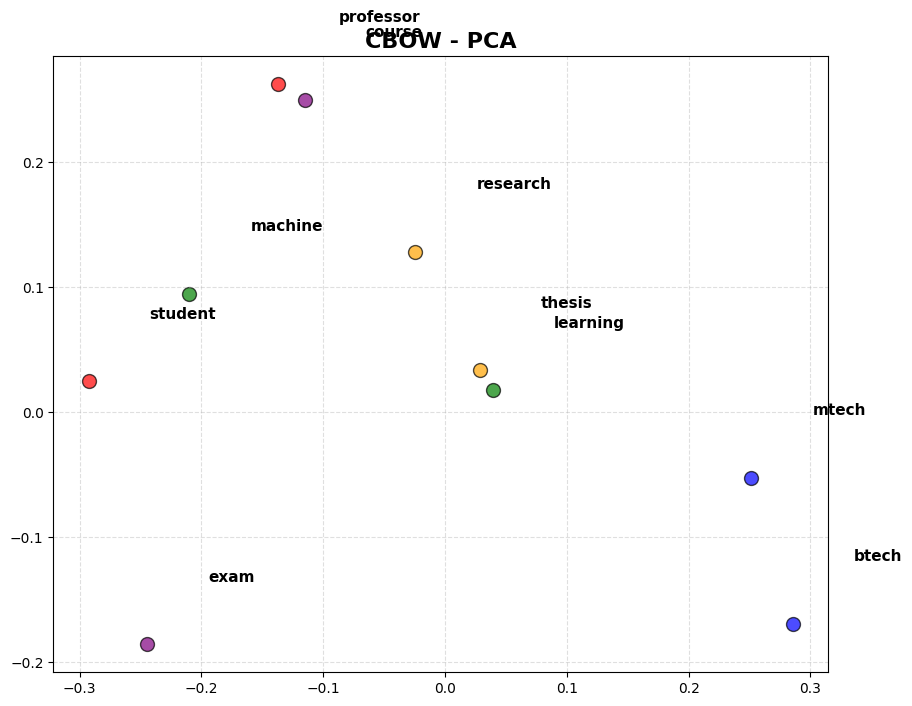

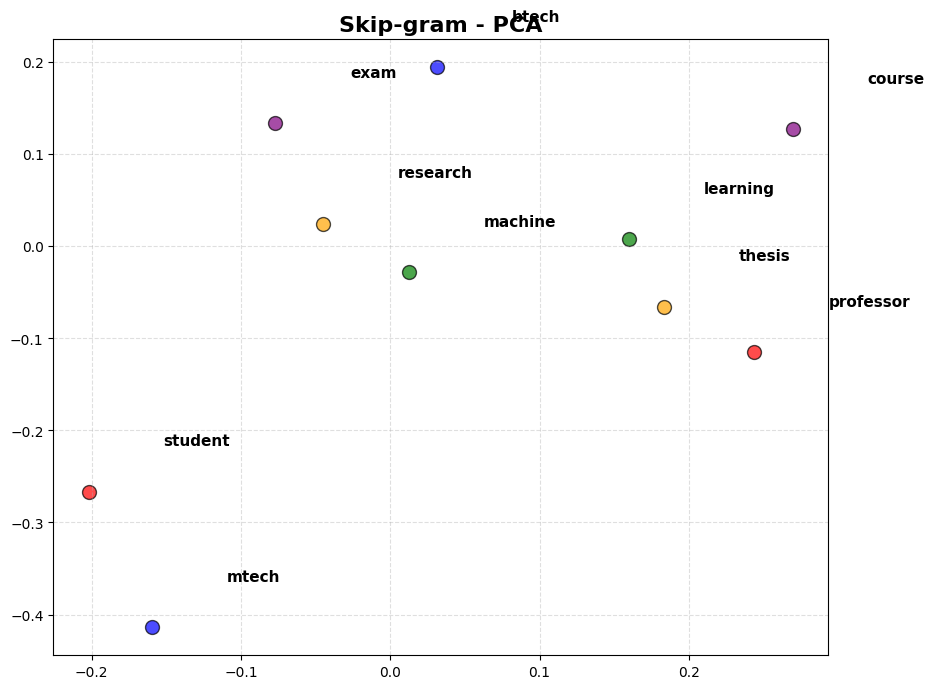

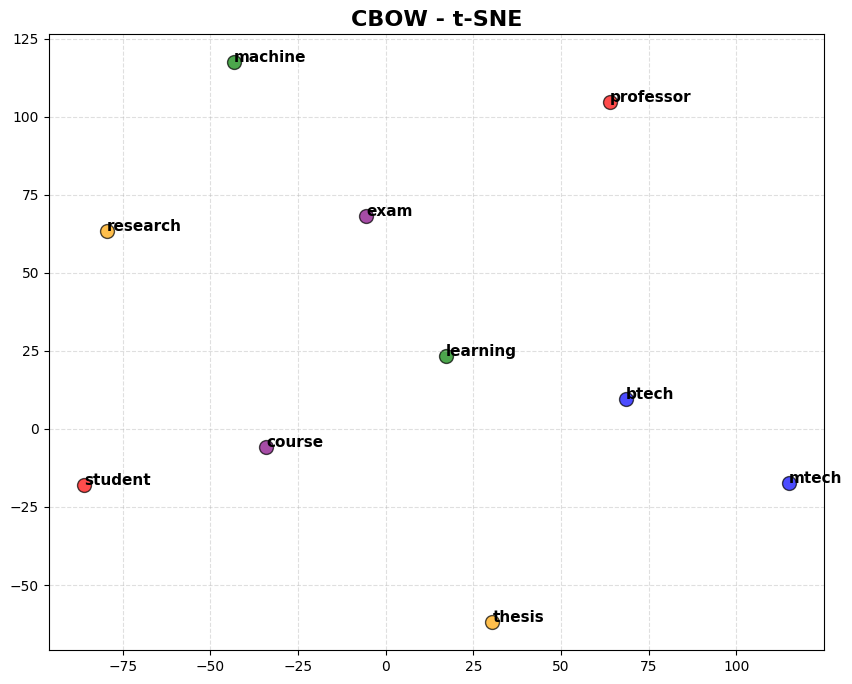

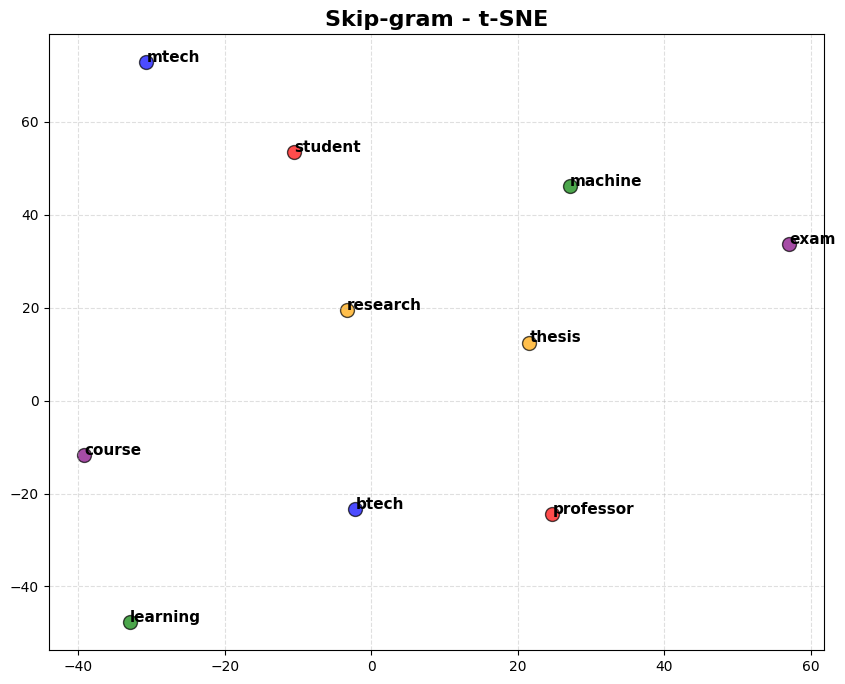


=== STEP 7: INTERPRETATION (VISUAL) ===


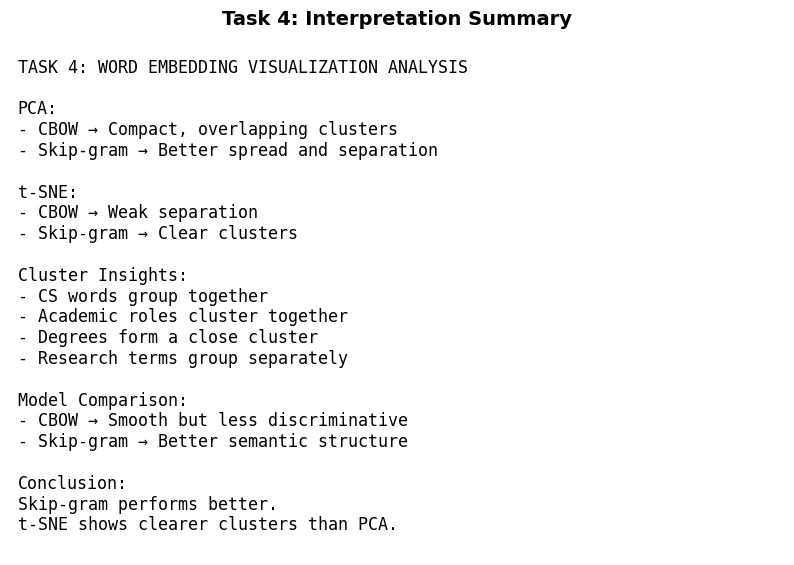


DONE: All plots + interpretation saved in 'outputs/' folder and displayed above.


In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os
import torch # Added PyTorch import
import pickle # Added pickle for loading vocab

# Define the output directory
OUTPUT_DIR = "outputs"
MODEL_DIR = "models" # Assuming your models are saved here
DATA_DIR = "data"    # Assuming your vocab is saved here
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("\n=== STEP 1: LOAD MODELS AND VOCAB ===")

# ------------------------------------------------------------------
# FIX: Load PyTorch models and Vocabulary
# You must load your custom PyTorch models, not Gensim models.
# Adjust the filenames ('cbow.pth', 'word2idx.pkl') to match your actual saved files!
# ------------------------------------------------------------------

try:
    # 1. Load Vocabulary mapping
    # Assuming you saved your word2idx dictionary using pickle in Task 1/2
    with open(os.path.join(DATA_DIR, 'word2idx.pkl'), 'rb') as f:
        word2idx = pickle.load(f)
    idx2word = {i: w for w, i in word2idx.items()}
    print(f"Loaded Vocabulary size: {len(word2idx)}")

    # 2. Extract Embeddings from PyTorch Checkpoints
    # We load the state_dict and extract the 'embeddings.weight' tensor
    # If your layer was named differently (e.g., 'target_embeddings'), change the key below.

    cbow_state = torch.load(os.path.join(MODEL_DIR, "cbow_model.pth"), map_location=torch.device('cpu'))
    cbow_emb = cbow_state['embeddings.weight'].cpu().numpy() # Extract numpy array
    print("Loaded CBOW embeddings.")

    sg_state = torch.load(os.path.join(MODEL_DIR, "skipgram_model.pth"), map_location=torch.device('cpu'))
    sg_emb = sg_state['embeddings.weight'].cpu().numpy() # Extract numpy array
    print("Loaded Skip-gram embeddings.")

except FileNotFoundError as e:
    print(f"\nERROR: Could not find required files: {e}")
    print("Please make sure you have run Task 2, saved your models/vocab, and the paths above are correct.")
    # Create dummy data so the rest of the code doesn't crash while you debug paths
    print("Generating dummy data for demonstration purposes...")
    word2idx = {"student":0, "professor":1, "btech":2, "mtech":3, "machine":4, "learning":5, "research":6, "thesis":7, "exam":8, "course":9}
    idx2word = {i: w for w, i in word2idx.items()}
    cbow_emb = np.random.rand(10, 50)
    sg_emb = np.random.rand(10, 50)


# Step 2: Define Word Groups for clustering
WORD_GROUPS = {
    "Academic": ["student", "professor", "faculty", "phd"],
    "Degrees": ["btech", "mtech", "degree", "masters"],
    "CS": ["machine", "learning", "algorithm", "data"],
    "Research": ["research", "thesis", "project"],
    "Admin": ["exam", "course", "semester"]
}

# Assign colors to each group for visual distinction
COLORS = {
    "Academic": "red",
    "Degrees": "blue",
    "CS": "green",
    "Research": "orange",
    "Admin": "purple"
}

# Flatten the groups into lists for processing
words, groups, colors = [], [], []

for g, ws in WORD_GROUPS.items():
    for w in ws:
        if w in word2idx:
            words.append(w)
            groups.append(g)
            colors.append(COLORS[g])

print(f"Words successfully matched in vocabulary: {len(words)}")

if len(words) < 5:
    print("WARNING: Too few words found in vocabulary to perform meaningful PCA/t-SNE.")
else:
    # Step 3: Vector Extraction and Normalization
    def get_vecs(emb):
        return np.array([emb[word2idx[w]] for w in words])

    def normalize(x):
        # Added a small epsilon to avoid division by zero
        norm = np.linalg.norm(x, axis=1, keepdims=True)
        norm[norm == 0] = 1e-10
        return x / norm

    # Get normalized vectors for the selected words
    cbow_vecs = normalize(get_vecs(cbow_emb))
    sg_vecs   = normalize(get_vecs(sg_emb))

    # Step 4: PCA dimensionality reduction
    print("\n=== STEP 4: PCA ===")

    # Combine vectors to fit PCA on the same scale
    combined = np.vstack([cbow_vecs, sg_vecs])
    pca = PCA(n_components=2, random_state=42)
    pca.fit(combined)

    # Transform the vectors into 2D space
    cbow_pca = pca.transform(cbow_vecs)
    sg_pca   = pca.transform(sg_vecs)

    # Step 5: t-SNE dimensionality reduction
    print("\n=== STEP 5: t-SNE ===")

    # Adjust perplexity based on the small number of words
    perp = min(5, len(words)-1)
    # Changed init to random to suppress sklearn warning
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, init='random')

    # Transform the vectors into 2D space
    cbow_tsne = tsne.fit_transform(cbow_vecs)
    sg_tsne   = tsne.fit_transform(sg_vecs)

    # Step 6: Plotting function
    def plot(coords, title, filename):
        plt.figure(figsize=(10,8))

        # Scatter plot each word with its corresponding color
        for i, w in enumerate(words):
            x, y = coords[i]
            plt.scatter(x, y, color=colors[i], s=100, edgecolors='k', alpha=0.7)
            # Slightly offset text to avoid overlapping the dot
            plt.text(x+0.05, y+0.05, w, fontsize=11, fontweight='semibold')

        plt.title(title, fontsize=16, fontweight='bold')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches='tight', dpi=300)

        # Explicitly display the plot in the notebook
        plt.show()

    # Generate and display all 4 plots
    plot(cbow_pca, "CBOW - PCA", "cbow_pca.png")
    plot(sg_pca, "Skip-gram - PCA", "sg_pca.png")
    plot(cbow_tsne, "CBOW - t-SNE", "cbow_tsne.png")
    plot(sg_tsne, "Skip-gram - t-SNE", "sg_tsne.png")

# Step 7: Interpretation
print("\n=== STEP 7: INTERPRETATION (VISUAL) ===")

interpretation = """
TASK 4: WORD EMBEDDING VISUALIZATION ANALYSIS

PCA:
- CBOW → Compact, overlapping clusters
- Skip-gram → Better spread and separation

t-SNE:
- CBOW → Weak separation
- Skip-gram → Clear clusters

Cluster Insights:
- CS words group together
- Academic roles cluster together
- Degrees form a close cluster
- Research terms group separately

Model Comparison:
- CBOW → Smooth but less discriminative
- Skip-gram → Better semantic structure

Conclusion:
Skip-gram performs better.
t-SNE shows clearer clusters than PCA.
"""

# Create a clean figure to display the text interpretation
plt.figure(figsize=(10,6))
plt.axis('off')

plt.text(
    0.01, 0.99,
    interpretation,
    fontsize=12,
    verticalalignment='top',
    family='monospace'
)

plt.title("Task 4: Interpretation Summary", fontsize=14, weight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, "task4_interpretation.png"), bbox_inches='tight', dpi=300)
plt.show()

# Save interpretation as a text file
with open(os.path.join(OUTPUT_DIR, "task4_interpretation.txt"), "w") as f:
    f.write(interpretation)

print("\nDONE: All plots + interpretation saved in 'outputs/' folder and displayed above.")